In [32]:
import os
import math
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import scipy
from scipy.stats import mannwhitneyu, pearsonr
from statsmodels.stats.multitest import multipletests

import itertools

import torch

import matplotlib.pyplot as plt
from plotnine import ggplot, aes, geom_line, theme_bw, theme, geom_point, geom_hline, annotate, scale_y_log10
import plotnine as p9
import seaborn as sns
import gc

In [33]:
sclembas_path = os.path.join(os.path.abspath('/home/hmbaghda/Projects/LEMBAS/'))

import sys
sys.path.insert(1, sclembas_path)

from LEMBAS.model.bionetwork import format_network, SignalingModel
from LEMBAS.benchmarking_version.benchmark_train import train_signaling_model
import LEMBAS.utilities as utils
from LEMBAS import plotting, io

In [34]:
n_cores = 12
utils.set_cores(n_cores)

seed = 888
if seed:
    torch.use_deterministic_algorithms(True)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    utils.set_seeds(seed = seed)
    
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# data_path = '/nobackup/users/hmbaghda/LEMBAS_benchmark/'

Load and format the data:

In [35]:
def inverse_sigmoid(y):
    return np.log(y / (1 - y))

In [36]:
net = pd.read_csv('https://zenodo.org/records/10815391/files/macrophage_network.tsv', sep = '\t', index_col = False)
ligand_input = pd.read_csv('https://zenodo.org/records/10815391/files/macrophage_ligands.tsv', sep = '\t', index_col = 0)
tf_output = pd.read_csv('https://zenodo.org/records/10815391/files/macrophage_TFs.tsv', sep='\t', low_memory=False, index_col=0)

untransformed_tf_output = inverse_sigmoid(tf_output)


In [37]:
stimulation_label = 'stimulation'
inhibition_label = 'inhibition'
weight_label = 'mode_of_action'
source_label = 'source'
target_label = 'target'
# Format network
net = format_network(net, weight_label = weight_label, stimulation_label = stimulation_label, inhibition_label = inhibition_label)



In [38]:
nodes = net[[source_label, target_label]].values.flatten()
tf_output = tf_output[[col for col in tf_output.columns if col in nodes]]
untransformed_tf_output = untransformed_tf_output[tf_output.columns]


Set up the model parameters:

In [39]:
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 'max_steps': 150, 'exp_factor':50, 'tolerance': 1e-5, 'leak':1e-2} # fed directly to model

# training parameters
lr_params = {'max_iter': 5000, 
            'learning_rate': 2e-3}
other_params = {'batch_size': 10, 'noise_level': 10, 'gradient_noise_level': 1e-9}
regularization_params = {'param_lambda_L2': 1e-6, 
                         'moa_lambda_L1': 0.1, 
                         'ligand_lambda_L2': 1e-5, 
                         'uniform_lambda_L2': 1e-4,
                         'uniform_max': 1/projection_amplitude_out, 
                         'spectral_loss_factor': 1e-5}
spectral_radius_params = {'n_probes_spectral': 5, 'power_steps_spectral': 5, 'subset_n_spectral': 5}
target_spectral_radius = 0.8
hyper_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params} # fed into training function



Set up training parameters:

In [40]:
# def models_are_allclose(model1, model2, rtol=1e-05, atol=1e-08):
#     for param1, param2 in zip(model1.parameters(), model2.parameters()):
#         if not np.allclose(param1.detach().cpu().numpy(), param2.detach().cpu().numpy(), rtol=rtol, atol=atol):
#             return False
#     return True


# # Check if the parameters are close (they should be identical here)
# models_are_allclose(mod_no_bias, mod_bias)



In [41]:
iter_dict = {'uniform': 0, 'L2_or_rand': 0, 'ProjectOutput_bias': 0}
bias_map = {0: tf_output.copy(), 1: untransformed_tf_output.copy()}
dict_to_bench_default = {'test_time': 0}

Find a CV split where there is no "zero-shot" learning (all individual ligands have been seen before):

LOO, but skip zero-shot learning ones:

In [42]:
k_folds = {}
samples = ligand_input.index.tolist()

zero_shot_samples = []

k = 0
for sample in samples:
    samples_ = samples.copy()
    samples_.remove(sample)
    
    X_train = ligand_input.loc[samples_, :]
    
    X_test = pd.DataFrame(ligand_input.loc[sample, :]).T
    y_test = pd.DataFrame(tf_output.loc[sample, :]).T    
    
    test_ligands = X_test.columns[(X_test != 0).any()]
    train_ligands = X_train.columns[(X_train != 0).any()]

    if len(set(test_ligands).difference(train_ligands)) != 0: # zero-shot
        zero_shot_samples.append(sample)
    else: 
        k_folds[k] = {'train': samples_, 
                     'test': sample}
        k += 1

In [43]:
zero_shot_samples

['GC', 'IL10', 'IL13']

Train and test the model:

In [44]:
def _train_model(mod, dict_to_bench, hyper_params, fn = None):
#     mod.X_in = mod.df_to_tensor(mod.X_in)
#     mod.y_out = mod.df_to_tensor(mod.y_out)

    
    mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
    mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

    # loss and optimizer
    loss_fn = torch.nn.MSELoss(reduction='mean')
    optimizer = torch.optim.Adam

    #
    res = train_signaling_model(mod, 
                                optimizer, 
                                loss_fn, 
                                reset_epoch = 200, 
                                hyper_params = hyper_params, 
                                train_seed = seed, 
                                verbose = False,
                                dict_to_bench=dict_to_bench, 
                               train_split_frac = {'train': 1, 'test': None, 'validation': None})

    mod, cur_loss, cur_eig, mean_loss, stats, _, _, _, _, _, _ = res
    if fn is not None:
#         torch.save(mod.state_dict(), fn)
        io.write_pickled_object(mod, fn)
        gradients = {name: param.grad for name, param in mod.named_parameters()}
        fn_grad = fn.replace('.pickle', '_gradients.pickle')
        io.write_pickled_object(gradients, fn_grad)
    return mod #, stats_df

def pearson_corr(tensor1, tensor2, axis=0):
    "Row- (axis = 0) or column- (axis=1) wise pearson correlation between two torch tensors."
    if axis == 1:
        tensor1 = tensor1.t()
        tensor2 = tensor2.t()
        
    mean1 = torch.mean(tensor1, dim=1, keepdim=True)
    mean2 = torch.mean(tensor2, dim=1, keepdim=True)

    tensor1_centered = tensor1 - mean1
    tensor2_centered = tensor2 - mean2
    covariance = torch.sum(tensor1_centered * tensor2_centered, dim=1)
    std1 = torch.sqrt(torch.sum(tensor1_centered ** 2, dim=1))
    std2 = torch.sqrt(torch.sum(tensor2_centered ** 2, dim=1))
    
    correlation = covariance / (std1 * std2)
    
    return correlation


def _evaluate_model(mod, X_test, y_test):
    X_test = mod.df_to_tensor(X_test)
    if len(X_test.shape) == 1: # 1 sample
        X_test = X_test.reshape(1,-1)

    tf_order = {k: v for k, v in mod.node_idx_map.items() if k in tf_output.columns}
    y_test = mod.df_to_tensor(y_test[sorted(tf_order, key=tf_order.get)])
    y_test = y_test.reshape(1,-1)

    mod.eval()
    with torch.inference_mode():
        Y_hat, _ = mod(X_test)
        loss_fn = torch.nn.MSELoss(reduction='mean')
        mse_loss = loss_fn(Y_hat, y_test).detach().cpu().numpy().item()
        corr_row = torch.nanmean(pearson_corr(Y_hat, y_test, axis=0)).cpu().numpy().item()

    return mse_loss, corr_row, Y_hat

In [45]:

# mod_consistency = pd.DataFrame(columns = ['k', 'condition_1', 'condition_2', 'prediction',
#                                       'signaling_weights', 
#                                       'signaling_bias',
#                                       'output_layer_weights', 
#                                       'signaling_weights_grad', 
#                                       'signaling_bias_grad',
#                                       'output_layer_weights_grad'])
# k_folds_res = pd.DataFrame(columns = ['k', 'mse', 'samples_pearson'] + iter_keys + ['param_lambda_L2'])
# curr_k = 0
# min_lambda = 1e-9

In [46]:
# for fn in [os.path.join(data_path, 'processed', 'benchmark_consistency.csv'), 
#           os.path.join(data_path, 'processed', 'benchmark_cv.csv')]:
#     print('rm ' + fn)
# print('')

In [47]:
for k in k_folds:
    break

In [50]:
# po_bias = iter_dict['ProjectOutput_bias']
# tf_output = bias_map[po_bias]
# hyper_params_k = hyper_params.copy()

# mod = SignalingModel(net = net,
#                      X_in = ligand_input.loc[k_folds[k]['train'], :],
#                      y_out = tf_output.loc[k_folds[k]['train'], :],
#                      projection_amplitude_in = projection_amplitude_in, 
#                      projection_amplitude_out = projection_amplitude_out,
#                      weight_label = weight_label, source_label = source_label, target_label = target_label,
#                      bionet_params = bionet_params,
#                      dtype = torch.float32, device = device, seed = seed)

# dict_to_bench = {**dict_to_bench_default, **iter_dict}
# dict_to_bench['name'] = 'trash'
# #                 fn = None if po_bias else os.path.join(data_path, 'processed', dict_to_bench['name'] + '.pickle')
# mod = _train_model(mod = mod, 
#                    dict_to_bench=dict_to_bench,
#                    hyper_params = hyper_params_k,
#                    fn = None)
# io.write_pickled_object(mod, 'lembas_original.pickle')
mod = io.read_pickled_object('lembas_original.pickle')

just before
[[ 596  649  732 ...  443  539  623]
 [   0    0    1 ... 1127 1127 1127]]
cuda


training: 100%|███████████████████████████████████████████████████████████████████████████| 5000/5000 [30:41<00:00,  2.72it/s]


In [25]:
weights = mod.signaling_network.weights.detach().cpu().numpy().flatten()
bias = mod.signaling_network.bias.detach().cpu().numpy().flatten()

Text(0.5, 0, 'Trained Bias Weights')

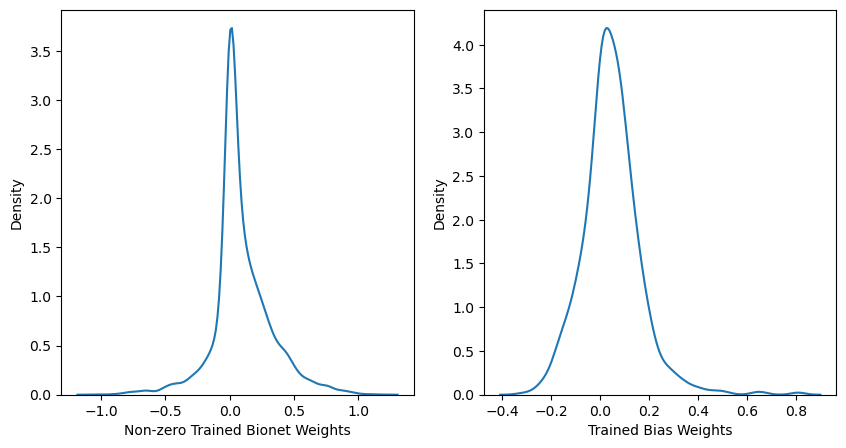

In [31]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))
sns.kdeplot(weights[weights != 0], ax = ax[0])
ax[0].set_xlabel('Non-zero Trained Bionet Weights')

sns.kdeplot(bias, ax = ax[1])
ax[1].set_xlabel('Trained Bias Weights')

Initialization check:

In [73]:
mod = SignalingModel(net = net,
                     X_in = ligand_input.loc[k_folds[k]['train'], :],
                     y_out = tf_output.loc[k_folds[k]['train'], :],
                     projection_amplitude_in = projection_amplitude_in, 
                     projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params,
                     dtype = torch.float32, device = device, seed = seed)
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

just before
[[ 596  649  732 ...  443  539  623]
 [   0    0    1 ... 1127 1127 1127]]


Text(0.5, 0, 'Initialized and Untrained Bias Weights')

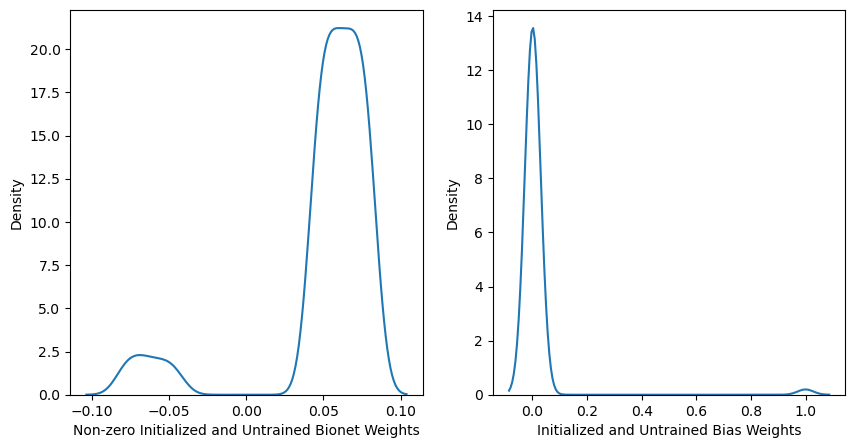

In [74]:
weights = mod.signaling_network.weights.detach().cpu().numpy().flatten()
bias = mod.signaling_network.bias.detach().cpu().numpy().flatten()

fig, ax = plt.subplots(ncols = 2, figsize = (10,5))
sns.kdeplot(weights[weights != 0], ax = ax[0])
ax[0].set_xlabel('Non-zero Initialized and Untrained Bionet Weights')

sns.kdeplot(bias, ax = ax[1])
ax[1].set_xlabel('Initialized and Untrained Bias Weights')

In [48]:
po_bias = iter_dict['ProjectOutput_bias']
tf_output = bias_map[po_bias]
hyper_params_k = hyper_params.copy()

In [57]:
net = net
X_in = ligand_input.loc[k_folds[k]['train'], :]
y_out = tf_output.loc[k_folds[k]['train'], :]
projection_amplitude_in = projection_amplitude_in
projection_amplitude_out = projection_amplitude_out
weight_label = weight_label
source_label = source_label
target_label = target_label
bionet_params = bionet_params
dtype = torch.float32
device = device
seed = seed
ban_list = None

In [62]:
class Test(torch.nn.Module):
    DEFAULT_TRAINING_PARAMETERS = {'target_steps': 100, 'max_steps': 300, 'exp_factor': 20, 'leak': 0.01, 'tolerance': 1e-5}

    def __init__(self):
        super().__init__()
    
    def parse_network(self, net: pd.DataFrame, ban_list = None, 
                 weight_label: str = 'mode_of_action', source_label: str = 'source', target_label: str = 'target'):
        """Parse adjacency network.
    
        Parameters
        ----------
        net: pd.DataFrame
            signaling network adjacency list with the following columns:
                - `weight_label`: whether the interaction is stimulating (1) or inhibiting (-1) or unknown (0). Exclude non-interacting (0)
                nodes. 
                - `source_label`: source node column name
                - `target_label`: target node column name
        ban_list : List[str], optional
            a list of signaling network nodes to disregard, by default None
    
        Returns
        -------
        edge_list : np.array
            a (2, net.shape[0]) array where the first row represents the indices for the target node and the 
            second row represents the indices for the source node. net.shape[0] is the total # of interactions
        node_labels : list
            a list of the network nodes in the same order as the indices
        edge_MOA : np.array
            a (2, net.shape[0]) array where the first row is a boolean of whether the interactions are stimulating and the 
            second row is a boolean of whether the interactions are inhibiting. 
            
            Note: Edge_list includes interactions that are not delineated as activating OR inhibiting, s.t. edge_MOA records this 
            as [False, False].
        """
        if not ban_list:
            ban_list = []
        if sorted(net[weight_label].unique()) != [-1, 0.1, 1]:
            raise ValueError(weight_label + ' values must be 1 or -1')
        
        net = net[~ net[source_label].isin(ban_list)]
        net = net[~ net[target_label].isin(ban_list)]
    
        # create an edge list with node incides
        node_labels = sorted(pd.concat([net[source_label], net[target_label]]).unique())
        self.node_idx_map = {idx: node_name for node_name, idx in enumerate(node_labels)}
        
        source_indices = net[source_label].map(self.node_idx_map).values
        target_indices = net[target_label].map(self.node_idx_map).values

        # # get edge list
        # edge_list = np.array((target_indices, source_indices))
        # edge_MOA = net[weight_label].values
        # get edge list *ordered by source-target node index*
        n_nodes = len(node_labels)
        A = scipy.sparse.csr_matrix((net[weight_label].values, (source_indices, target_indices)), shape=(n_nodes, n_nodes)) # calculate adjacency matrix
        source_indices, target_indices, edge_MOA = scipy.sparse.find(A) # re-orders adjacency list by index
        edge_list = np.array((target_indices, source_indices)) 
        edge_MOA = np.array([[edge_MOA==1],[edge_MOA==-1]]).squeeze() # convert to boolean

        return edge_list, node_labels, edge_MOA
    
    def set_training_parameters(self, **attributes):
        """Set the parameters for training the model. Overrides default parameters with attributes if specified.
        Adapted from LEMBAS `trainingParameters`
    
        Parameters
        ----------
        attributes : dict
            keys are parameter names and values are parameter value
        """
        #set defaults
        default_parameters = self.DEFAULT_TRAINING_PARAMETERS.copy()
        allowed_params = list(default_parameters.keys()) + ['spectral_target']
    
        params = {**default_parameters, **attributes}
        if 'spectral_target' not in params.keys():
            params['spectral_target'] = np.exp(np.log(params['tolerance'])/params['target_steps'])
    
        params = {k: v for k,v in params.items() if k in allowed_params}
    
        return params
    
    
self = Test()

In [63]:
self.dtype = dtype
self.device = device
self.seed = seed
self._gradient_seed_counter = 0
self.projection_amplitude_out = projection_amplitude_out

edge_list, node_labels, edge_MOA = self.parse_network(net, ban_list, weight_label, source_label, target_label)
print("just before")
print(edge_list)

# Save edge_list to a .txt file
#np.savetxt("edge_list.txt", edge_list, fmt='%s', delimiter='\t')  # Adjust fmt and delimiter as needed


if not bionet_params:
    bionet_params = self.DEFAULT_TRAINING_PARAMETERS.copy()
else:
    bionet_params = self.set_training_parameters(**bionet_params)

# filter for nodes in the network, sorting by node_labels order
self.X_in = X_in.loc[:, np.intersect1d(X_in.columns.values, node_labels)]
self.y_out = y_out.loc[:, np.intersect1d(y_out.columns.values, node_labels)]

from LEMBAS.model.bionetwork import ProjectInput
# define model layers
self.input_layer = ProjectInput(node_idx_map = self.node_idx_map, 
                                input_labels = self.X_in.columns.values, 
                                projection_amplitude = projection_amplitude_in, 
                                dtype = self.dtype, 
                                device = self.device)

just before
[[ 596  649  732 ...  443  539  623]
 [   0    0    1 ... 1127 1127 1127]]


In [67]:
from LEMBAS.model.model_utilities import np_to_torch
edge_list = edge_list 
edge_MOA = edge_MOA 
n_network_nodes = len(node_labels) 
bionet_params = bionet_params 
activation_function = 'MML' 
dtype = self.dtype
device = self.device
seed = self.seed

In [69]:
self.training_params = bionet_params
self.dtype = dtype
self.device = device
self.seed = seed
self._ss_seed_counter = 0

self.n_network_nodes = n_network_nodes
# TODO: delete these _in _out?
self.n_network_nodes_in = n_network_nodes
self.n_network_nodes_out = n_network_nodes

self.edge_list = (np_to_torch(edge_list[0,:], dtype = torch.int32, device = 'cpu'), 
                  np_to_torch(edge_list[1,:], dtype = torch.int32, device = 'cpu'))
self.edge_MOA = np_to_torch(edge_MOA, dtype=torch.bool, device = self.device)

In [51]:



self.signaling_network = BioNet(edge_list = edge_list, 
                                edge_MOA = edge_MOA, 
                                n_network_nodes = len(node_labels), 
                                bionet_params = bionet_params, 
                                activation_function = activation_function, 
                                dtype = self.dtype, device = self.device, seed = self.seed)
self.output_layer = ProjectOutput(node_idx_map = self.node_idx_map, 
                                  output_labels = self.y_out.columns.values, 
                                  projection_amplitude = self.projection_amplitude_out, 
                                  dtype = self.dtype, device = device)